In [46]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.image import imread

In [47]:
my_data_dir = 'C:\\Users\\Gauriel\\Gabikir99\\Desktop\\cell_images\\cell_images'

In [48]:
os.listdir(my_data_dir) 

['test', 'train']

In [49]:
test_path = my_data_dir+'\\test\\'
train_path = my_data_dir+'\\train\\'

In [50]:
os.listdir(test_path)

['parasitized', 'uninfected']

In [51]:
os.listdir(train_path)

['parasitized', 'uninfected']

In [52]:
os.listdir(train_path+'\\parasitized')[2]

'C100P61ThinF_IMG_20150918_144104_cell_164.png'

In [53]:
para_cell = train_path+'\\parasitized'+'\\C100P61ThinF_IMG_20150918_144104_cell_164.png'

In [54]:
para_img= imread(para_cell)

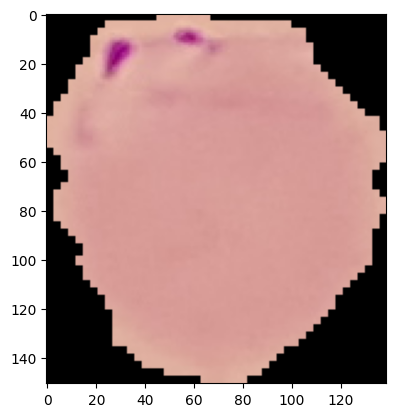

In [55]:
plt.imshow(para_img)

In [56]:
para_img.shape

(151, 139, 3)

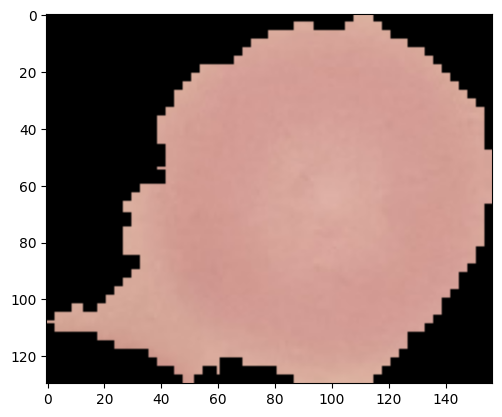

In [57]:
unifected_cell_path = train_path+'\\uninfected\\'+os.listdir(train_path+'\\uninfected')[5]
unifected_cell = imread(unifected_cell_path)
plt.imshow(unifected_cell)

In [58]:
len(os.listdir(train_path+'\\parasitized'))

12480

In [59]:
len(os.listdir(train_path+'\\uninfected'))

12480

**Average Dimension of the images**

In [60]:
unifected_cell.shape

(130, 157, 3)

In [61]:
para_img.shape

(151, 139, 3)

In [62]:
dim1 = []
dim2 = []
for image_filename in os.listdir(test_path+'\\uninfected'):
    
    img = imread(test_path+'\\uninfected'+'\\'+image_filename)
    d1,d2,colors = img.shape
    dim1.append(d1)
    dim2.append(d2)

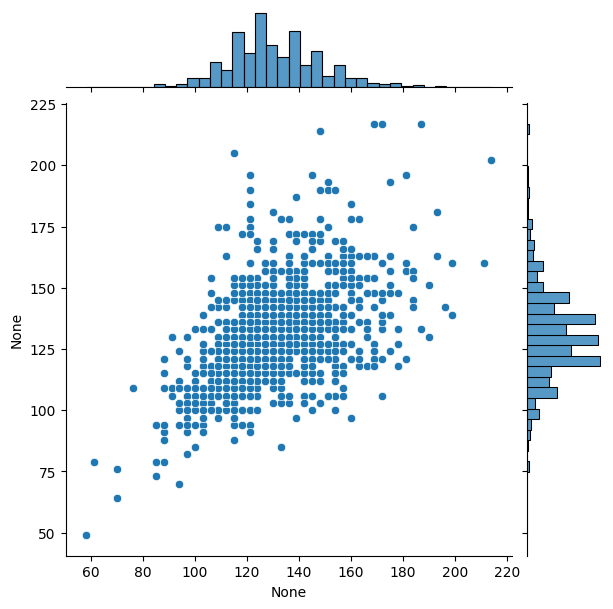

In [63]:
sns.jointplot(x=dim1,y=dim2)

In [64]:
np.mean(dim1)

np.float64(130.92538461538462)

In [65]:
np.mean(dim2)

np.float64(130.75)

In [66]:
image_shape = (130,130,3)

In [67]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [68]:
image_gen = ImageDataGenerator(rotation_range=20, 
                               width_shift_range=0.10, 
                               height_shift_range=0.10, 
                               rescale=1/255, 
                               shear_range=0.1, 
                               zoom_range=0.1, 
                               horizontal_flip=True, 
                               fill_mode='nearest' 
                              )

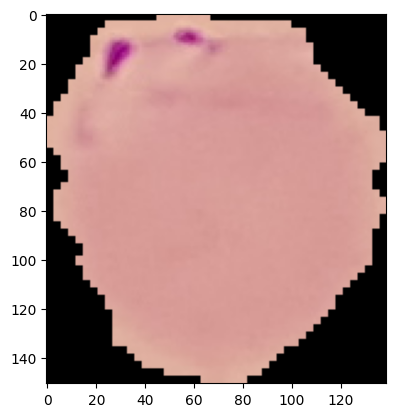

In [69]:
plt.imshow(para_img)

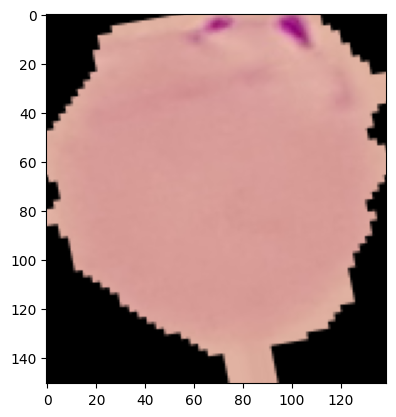

In [70]:
plt.imshow(image_gen.random_transform(para_img))

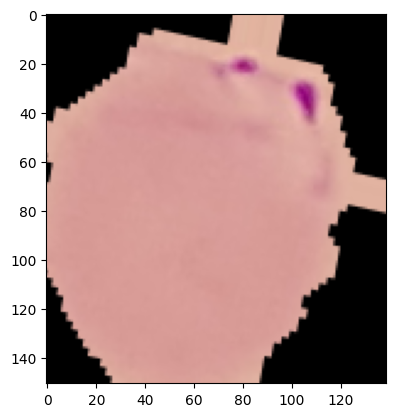

In [71]:
plt.imshow(image_gen.random_transform(para_img))

In [72]:
image_gen.flow_from_directory(train_path)

Found 24958 images belonging to 2 classes.


In [73]:
image_gen.flow_from_directory(test_path)

Found 2600 images belonging to 2 classes.


# Creating the Model

In [97]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dense, Dropout, Activation, GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2

In [99]:
model = Sequential()

model.add(Conv2D(16, (3,3), padding='same', kernel_regularizer=l2(1e-4), input_shape=image_shape))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(32, (3,3), padding='same', kernel_regularizer=l2(1e-4)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

model.add(GlobalAveragePooling2D())

model.add(Dense(64, kernel_regularizer=l2(1e-4)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))

model.add(Dense(32, kernel_regularizer=l2(1e-4)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))

model.add(Dense(1))
model.add(Activation('sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [100]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 130, 130, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 130, 130, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 130, 130, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 65, 65, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 65, 65, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 65, 65, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_29 (Activation)      │ (None, 65, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_32 (Activation)      │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,889 (38.63 KB)

 Trainable params: 9,601 (37.50 KB)

 Non-trainable params: 288 (1.12 KB)

## Early Stopping

In [101]:
from tensorflow.keras.callbacks import EarlyStopping

In [102]:
early_stop = EarlyStopping(monitor='val_loss',patience=3)

## Training the Model

In [103]:
batch_size = 32

In [104]:
train_image_gen = image_gen.flow_from_directory(train_path,
                                               target_size=image_shape[:2],
                                                color_mode='rgb',
                                               batch_size=batch_size,
                                               class_mode='binary')

Found 24958 images belonging to 2 classes.


In [105]:
test_image_gen = image_gen.flow_from_directory(test_path,
                                               target_size=image_shape[:2],
                                               color_mode='rgb',
                                               batch_size=batch_size,
                                               class_mode='binary',
                                               shuffle=False)

Found 2600 images belonging to 2 classes.


In [106]:
train_image_gen.class_indices

{'parasitized': 0, 'uninfected': 1}

In [107]:
import warnings
warnings.filterwarnings('ignore')

In [108]:
results = model.fit(train_image_gen,epochs=50, validation_data=test_image_gen, callbacks=[early_stop])

Epoch 1/50
780/780 ━━━━━━━━━━━━━━━━━━━━ 168s 214ms/step - accuracy: 0.6329 - loss: 0.7180 - val_accuracy: 0.8135 - val_loss: 0.4424
Epoch 2/50
780/780 ━━━━━━━━━━━━━━━━━━━━ 163s 209ms/step - accuracy: 0.8626 - loss: 0.3737 - val_accuracy: 0.7015 - val_loss: 0.5928
Epoch 3/50
283/780 ━━━━━━━━━━━━━━━━━━━━ 1:50 223ms/step - accuracy: 0.8904 - loss: 0.3115

KeyboardInterrupt: 